# Squat Session Analysis

Loads a session log produced by `src/squat_analyzer.py --export ...` and
plots knee-angle trajectory, rep boundaries, and depth quality.

This notebook runs against `data/sample_session/pose_session_example.json`,
a **synthetic** session (documented in the file itself) used to keep the
notebook runnable without needing a real recorded workout on hand — swap
in any real exported session JSON and it works the same way.


In [1]:
import json
import matplotlib.pyplot as plt

with open("../data/sample_session/pose_session_example.json") as f:
    session = json.load(f)

print(session.get("_note", ""))
summary = session["summary"]
summary


Synthetic demo session for testing analysis notebook — not a real recorded workout


{'total_reps': 5,
 'reps_at_parallel_or_below': 4,
 'success_rate_pct': 80.0,
 'best_depth_deg': 77.4,
 'average_depth_deg': 85.8,
 'rep_depths_deg': [80.7, 90.6, 77.4, 96.7, 83.6],
 'frames_processed': 250}

## Knee angle over time, coloured by phase

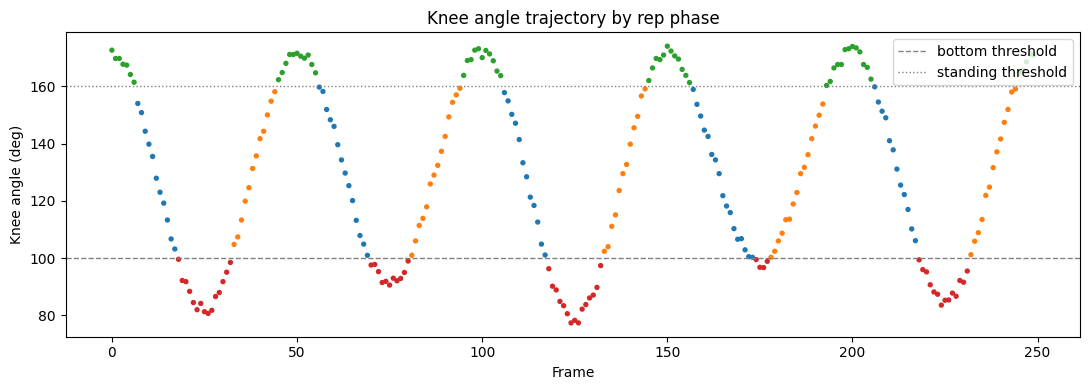

In [2]:
frames = session["frame_log"]
x = [f["frame"] for f in frames]
y = [f["knee_angle_deg"] for f in frames]
phases = [f["phase"] for f in frames]

phase_colours = {
    "standing": "#2ca02c",
    "descending": "#1f77b4",
    "bottom": "#d62728",
    "ascending": "#ff7f0e",
}
colours = [phase_colours.get(p, "gray") for p in phases]

plt.figure(figsize=(11, 4))
plt.scatter(x, y, c=colours, s=8)
plt.xlabel("Frame")
plt.ylabel("Knee angle (deg)")
plt.title("Knee angle trajectory by rep phase")
plt.axhline(100, linestyle="--", color="gray", linewidth=1, label="bottom threshold")
plt.axhline(160, linestyle=":", color="gray", linewidth=1, label="standing threshold")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../results/knee_angle_trajectory.png", dpi=150)
plt.show()


## Per-rep depth quality

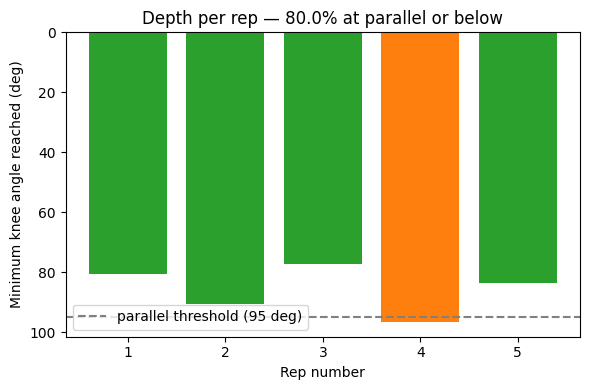

In [3]:
depths = summary["rep_depths_deg"]
reps = list(range(1, len(depths) + 1))
colours = ["#2ca02c" if d <= 95 else "#ff7f0e" for d in depths]

plt.figure(figsize=(6, 4))
bars = plt.bar(reps, depths, color=colours)
plt.axhline(95, linestyle="--", color="gray", label="parallel threshold (95 deg)")
plt.xlabel("Rep number")
plt.ylabel("Minimum knee angle reached (deg)")
plt.title(f"Depth per rep — {summary['success_rate_pct']}% at parallel or below")
plt.gca().invert_yaxis()  # lower angle = deeper, show deeper reps as taller bars
plt.legend()
plt.tight_layout()
plt.savefig("../results/depth_per_rep.png", dpi=150)
plt.show()


## Summary

- **Total reps:** see `summary['total_reps']`
- **Reps at parallel or below:** `summary['reps_at_parallel_or_below']`
- **Best depth:** `summary['best_depth_deg']` degrees

The threshold-crossing rep-counting logic (see `src/rep_counter.py`) is what
makes this robust to per-frame MediaPipe jitter — see
`tests/test_rep_counter.py::test_counts_correctly_with_realistic_noise` for
the regression test that would catch a return to naive local-minima
detection.
